<center>


<div style="display: flex; justify-content: center;">
    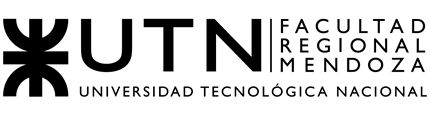
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Ingeniería en Electrónica</strong></p>
        <p><strong>Ingeniería en Telecomunicaciones</strong></p>
    </div>
</center>

# Módulo 4 — Estructuras de control

Hasta acá tu código se ejecuta **siempre igual**, línea por línea, de arriba hacia abajo. En este módulo vamos a darle al programa dos capacidades nuevas y fundamentales:

- **Decidir**: ejecutar cierto bloque de código solo si se cumple una condición.
- **Repetir**: ejecutar cierto bloque de código varias veces, recorriendo una colección o hasta que se cumpla una condición.

Con estas dos herramientas — más lo que ya viste de tipos y colecciones — recién ahora se puede empezar a *programar* en serio. Un filtrado de valores, un promedio, una búsqueda, una simulación iterativa: todo se apoya en decidir y repetir.

Los temas de este módulo son:

| Herramienta | Para qué sirve |
|-------------|----------------|
| `if / elif / else` | Tomar decisiones |
| `for` | Recorrer una colección o una secuencia de números |
| `while` | Repetir mientras se cumpla una condición |
| `break` y `continue` | Cortar o saltear iteraciones |
| Comprensiones de lista | Construir listas de manera compacta |

## 1. Condicionales: `if`, `elif`, `else`

Un condicional ejecuta un bloque de código **solo si** una condición es verdadera. La sintaxis es:

```python
if condición:
    # se ejecuta si la condición es True
elif otra_condición:
    # se ejecuta si la anterior fue False y esta es True
else:
    # se ejecuta si ninguna de las anteriores fue True
```

Las ramas `elif` (abreviatura de *else if*) y `else` son opcionales: podés tener un `if` solo, un `if`+`else`, o cualquier cantidad de `elif` en el medio.

### Indentación: importante

En Python **el indentado define los bloques**. Todo lo que va indentado bajo el `if:` pertenece al `if`; en cuanto escribís una línea al mismo nivel del `if`, el bloque se cerró. La convención es usar **4 espacios** por nivel (Colab te lo hace automático cuando presionás Tab).

No son decorativos: si indentás mal, el código no corre o se comporta distinto. Es parte de la sintaxis del lenguaje.

In [ ]:
numero = 10

if numero > 0:
    print("El número es positivo.")
elif numero < 0:
    print("El número es negativo.")
else:
    print("El número es cero.")

### Combinar condiciones

En el Módulo 2 viste los operadores de comparación (`==`, `!=`, `<`, `<=`, `>`, `>=`) y los lógicos (`and`, `or`, `not`). Todo eso se usa naturalmente dentro de un `if`:

In [ ]:
tension = 12.3

if 11.5 <= tension <= 12.5:
    print("Tensión dentro del rango esperado.")
else:
    print("Tensión fuera de rango.")

Fijate en el detalle `11.5 <= tension <= 12.5`: Python permite **encadenar comparaciones**, lo cual se lee casi igual que en matemática. Es equivalente a `(11.5 <= tension) and (tension <= 12.5)`, pero más corto y claro.

### `if` dentro de `if`

Una rama puede contener a su vez otro `if`. Cada nivel agrega una indentación más:

In [ ]:
tension = 12.3
tolerancia = 0.2

if tension > 0:
    if abs(tension - 12) <= tolerancia:
        print("Alimentación de 12 V dentro de tolerancia.")
    else:
        print("Tensión positiva pero fuera de tolerancia.")
else:
    print("Tensión no positiva; revisar conexión.")

> **Nota sobre `abs()`:** devuelve el valor absoluto (la distancia a cero) de un número. Ya la usaste en el Módulo 2 para el módulo de un complejo; sobre un número real, `abs(-3.5)` da `3.5`.

### Actividad 1: clasificar una tensión

Tenés una medición de tensión en volts y querés clasificarla en tres categorías según su valor absoluto:

- **"baja"** si es menor a `11.5`
- **"normal"** si está entre `11.5` y `12.5` (inclusive)
- **"alta"** si es mayor a `12.5`

Escribí un bloque `if / elif / else` que, dada la variable `tension`, imprima la categoría correspondiente. Probá tu código cambiando el valor inicial de `tension` para verificar que las tres ramas funcionan.

In [ ]:
tension = 12.1

# TU CÓDIGO AQUÍ

## 2. Bucle `for`: recorrer una colección

El bucle `for` ejecuta un bloque de código **una vez por cada elemento** de una colección. Su sintaxis es:

```python
for variable in colección:
    # bloque que se ejecuta para cada elemento
```

En cada vuelta, `variable` toma el valor del siguiente elemento de la colección. Ya viste un anticipo al final del Módulo 3; ahora lo formalizamos.

In [ ]:
temperaturas = [18.5, 19.0, 20.1, 21.3, 20.8, 19.4]

for t in temperaturas:
    print(t)

El bucle también funciona sobre strings (recorre los caracteres) y sobre conjuntos y tuplas. Básicamente, cualquier cosa que se pueda "recorrer":

In [ ]:
for letra in "Python":
    print(letra)

### Acumulador: el patrón más común

Una de las cosas que más se hace con un `for` es **acumular** un resultado: sumar, contar, buscar el máximo, etc. La receta es siempre la misma:

1. Inicializar una variable "acumuladora" antes del `for`.
2. En cada iteración, actualizarla según el elemento actual.
3. Al terminar el `for`, la variable tiene el resultado.

In [ ]:
temperaturas = [18.5, 19.0, 20.1, 21.3, 20.8, 19.4]

total = 0
for t in temperaturas:
    total = total + t

promedio = total / len(temperaturas)
print(f"Suma:     {total}")
print(f"Promedio: {promedio}")

> **Nota:** para la suma podrías haber usado directamente `sum(temperaturas)` (lo vimos en M03). Acá el punto no es reemplazar a `sum()`, sino ver el patrón del acumulador, que vas a usar en muchísimas situaciones donde `sum()` no alcanza.

### `range()`: generar una secuencia de números

A veces no querés recorrer una colección existente, sino simplemente **repetir N veces** un bloque, o recorrer una secuencia de enteros. Para eso está `range()`:

- `range(n)` → los enteros desde `0` hasta `n-1`.
- `range(a, b)` → desde `a` hasta `b-1`.
- `range(a, b, paso)` → desde `a`, sumando `paso`, mientras sea menor que `b`.

In [ ]:
for i in range(5):
    print(i)

In [ ]:
for i in range(2, 10, 2):
    print(i)

> **Observación.** `range()` no devuelve una lista, pero se comporta como una para el `for`. Si querés verla como lista, usá `list(range(5))`. La convención es usar `i`, `j`, `k` para los contadores; cuando el contador no se usa dentro del bucle, también es habitual escribir `_` en su lugar: `for _ in range(3): ...`.

### `enumerate()`: recorrer con índice

A veces, mientras recorrés una lista, también necesitás saber **la posición** de cada elemento. Podrías hacerlo con `range(len(...))`, pero Python ofrece algo más limpio: `enumerate()`, que en cada iteración entrega el par `(índice, elemento)`.

In [ ]:
muestras = [0.0, 0.5, 0.9, 1.0, 0.9, 0.5]

for i, valor in enumerate(muestras):
    print(f"muestra {i}: {valor}")

Fijate en el desempacado automático de la tupla `(i, valor)`: es el mismo patrón que viste en el Módulo 3. Usar `enumerate()` es más claro que escribir `muestras[i]` a mano y además evita errores con los índices.

### Recorrer un diccionario

Un `for` directo sobre un diccionario recorre sus **claves**. Si necesitás clave y valor a la vez, lo más cómodo es usar `.items()`:

In [ ]:
resistor = {
    "nombre": "R1",
    "valor": 220,
    "unidad": "ohm",
    "tolerancia": 5,
}

for clave, valor in resistor.items():
    print(f"{clave:12s} → {valor}")

> **Detalle del f-string:** `{clave:12s}` alinea el texto a la izquierda usando **12 caracteres**. Es un pequeño recurso para que las salidas salgan prolijas en columnas.

### Actividad 2: analizar una lista de muestras

Partiendo de estas muestras (en volts) tomadas cada 1 ms:

```python
muestras = [0.0, 0.3, 0.7, 1.1, 1.4, 1.2, 0.8, 0.4, 0.0, -0.3, -0.6]
```

1. Usando un `for` con **acumulador**, calculá la **suma** de las muestras (no uses `sum()`). Guardala en `suma`.
2. Usando un `for` con **acumulador**, contá cuántas muestras son **mayores que 1.0**. Guardá el resultado en `cuenta_altas`.
3. Usando `enumerate()`, imprimí con un f-string el índice y el valor de cada muestra **que supere `1.0`**, en el formato `"índice 3: 1.1 V"`.

In [ ]:
muestras = [0.0, 0.3, 0.7, 1.1, 1.4, 1.2, 0.8, 0.4, 0.0, -0.3, -0.6]

# TU CÓDIGO AQUÍ

## 3. Bucle `while`: repetir mientras se cumpla una condición

El `while` es parecido al `for` pero en vez de recorrer una colección, se ejecuta **mientras una condición sea verdadera**. La sintaxis es:

```python
while condición:
    # bloque que se repite mientras la condición sea True
```

Antes de cada iteración, Python evalúa la condición. Si da `True`, ejecuta el bloque; cuando da `False`, sale del bucle.

In [ ]:
contador = 1

while contador <= 5:
    print(contador)
    contador = contador + 1

> **Atajo útil.** `contador = contador + 1` se puede escribir como `contador += 1`. Lo mismo vale con `-=`, `*=`, `/=`: son simplemente formas abreviadas.

### Cuidado con los bucles infinitos

El bucle `while` **depende de vos** para terminar: si la condición nunca se vuelve falsa, el programa queda atrapado repitiendo para siempre. Por ejemplo, si te olvidás de incrementar el contador:

```python
contador = 1
while contador <= 5:
    print(contador)
    # ¡nos olvidamos de contador += 1 !
```

En Colab, un bucle infinito se nota porque la celda nunca termina de ejecutarse (el indicador circular sigue girando). Si te pasa, podés detenerlo con el botón ⏹ de la celda o desde *Runtime → Interrupt execution*.

**Regla de oro:** siempre que escribas un `while`, verificá que haya algo **dentro** del bloque que haga avanzar la condición hacia `False`.

### `for` vs `while`

¿Cuándo conviene cada uno?

- Usá **`for`** cuando sabés **sobre qué** vas a iterar (una lista, un rango, etc.).
- Usá **`while`** cuando no sabés de antemano cuántas iteraciones harán falta: el bucle termina cuando **se cumpla una condición**.

Un ejemplo típico del segundo caso: "iterar hasta que el error sea menor a cierto umbral", muy común en algoritmos iterativos.

### Actividad 3: carga de un capacitor

Un capacitor se carga a través de una resistencia desde cero volts. La tensión en cada paso se actualiza según

$$v_{k+1} = v_k + \alpha \cdot (V_f - v_k)$$

donde $V_f = 5$ V es la tensión final y $\alpha = 0.1$ es un factor que depende del paso de tiempo. Querés saber **cuántos pasos** hacen falta hasta que la tensión del capacitor supere el 99 % del valor final (es decir, `0.99 * V_f`).

1. Partí de `v = 0.0`, `pasos = 0`, `V_f = 5.0`, `alpha = 0.1`.
2. Escribí un bucle `while` que repita la actualización mientras `v` sea **menor** a `0.99 * V_f`, incrementando `pasos` en cada iteración.
3. Al salir del bucle, mostrá con un f-string: `"Se alcanzó el 99 % en {pasos} pasos, con v = {v:.4f} V"`.

> Tip: asegurate de actualizar `v` **dentro** del bucle; si no, te vas a quedar en un bucle infinito.

In [ ]:
V_f = 5.0
alpha = 0.1
v = 0.0
pasos = 0

# TU CÓDIGO AQUÍ

## 4. `break` y `continue`: modificar el flujo del bucle

Dentro de un `for` o un `while`, Python ofrece dos sentencias que alteran el curso normal:

- **`break`**: sale del bucle inmediatamente, aunque queden elementos por recorrer.
- **`continue`**: saltea el resto del bloque y pasa a la siguiente iteración.

In [ ]:
# Buscar la primera muestra que supere un umbral
muestras = [0.2, 0.5, 0.9, 1.4, 0.3, 1.8]
umbral = 1.0

for i, valor in enumerate(muestras):
    if valor > umbral:
        print(f"Primera muestra sobre el umbral: índice {i}, valor {valor}")
        break

In [ ]:
# Imprimir solo las muestras positivas (salteando las negativas)
muestras = [0.5, -0.3, 0.8, -0.1, 0.0, 1.2]

for valor in muestras:
    if valor < 0:
        continue
    print(valor)

En el primer ejemplo, el `break` corta el bucle no bien se encuentra la primera muestra sobre el umbral: no seguimos revisando el resto, porque ya tenemos lo que buscábamos. En el segundo, el `continue` saltea las muestras negativas y sigue con la próxima.

Usados con moderación, `break` y `continue` hacen el código más claro. Abusados — con varios anidados — lo vuelven difícil de seguir.

## 5. Comprensiones de lista

Muy seguido uno quiere construir **una lista nueva** a partir de otra: por ejemplo, convertir cada valor a otras unidades, o filtrar los que cumplan cierta condición. Se puede hacer con un `for` de acumulador y `append()`:

In [ ]:
temperaturas_c = [18.5, 19.0, 20.1, 21.3, 20.8, 19.4]

temperaturas_k = []
for t in temperaturas_c:
    temperaturas_k.append(t + 273.15)

print(temperaturas_k)

Python ofrece una forma mucho más compacta para este patrón, llamada **comprensión de lista** (*list comprehension*):

```python
[expresión for elemento in colección]
```

La misma conversión Celsius → Kelvin se escribe en una línea:

In [ ]:
temperaturas_c = [18.5, 19.0, 20.1, 21.3, 20.8, 19.4]

temperaturas_k = [t + 273.15 for t in temperaturas_c]
print(temperaturas_k)

Se lee casi como inglés: *"tomá cada `t` en `temperaturas_c`, y armá una lista con `t + 273.15`"*. La variable `t` existe solo dentro de la comprensión.

### Con condición

Se puede agregar un `if` al final para **filtrar** qué elementos entran en la lista:

```python
[expresión for elemento in colección if condición]
```

In [ ]:
muestras = [0.2, -0.5, 0.9, 1.4, -0.3, 1.8, 0.0]

positivas = [x for x in muestras if x > 0]
print(positivas)

Y por supuesto se pueden combinar: una transformación **y** un filtro al mismo tiempo.

In [ ]:
muestras = [0.2, -0.5, 0.9, 1.4, -0.3, 1.8, 0.0]

# Módulo de cada muestra, solo si es distinta de cero
modulos_no_nulos = [abs(x) for x in muestras if x != 0]
print(modulos_no_nulos)

> **Cuándo usarlas.** Las comprensiones son ideales para transformaciones o filtros simples en una sola línea. Si la lógica adentro se vuelve compleja (varios `if`, cálculos largos), es más legible volver a un `for` clásico con `append()`.

### Actividad 4: comprensiones sobre una señal

Dada esta lista de muestras de una señal (en volts):

```python
muestras = [-0.8, -0.2, 0.0, 0.3, 0.7, 1.1, 1.4, 1.2, 0.8, 0.4, -0.1, -0.5]
```

Usando **comprensiones de lista** (una por cada punto):

1. Armá `cuadrados` con el **cuadrado** de cada muestra.
2. Armá `positivas` con las muestras **estrictamente mayores que cero**.
3. Armá `recortadas` donde cada valor sea el original **si está entre −1 y 1**, o el valor más cercano del intervalo en caso contrario (pista: podés usar un `if/else` dentro de la expresión, con la forma `valor_si_cumple if condición else valor_si_no`).

Mostrá las tres listas.

In [ ]:
muestras = [-0.8, -0.2, 0.0, 0.3, 0.7, 1.1, 1.4, 1.2, 0.8, 0.4, -0.1, -0.5]

# TU CÓDIGO AQUÍ

## 6. Integrador: recorrer un diccionario con un `if`

Para cerrar, un ejemplo que combina varios de los temas del módulo: recorrer un diccionario con `for ... items()` y clasificar cada entrada con un `if`.

In [ ]:
componentes = {
    "R1": 220,
    "R2": 1000,
    "R3": 4700,
    "R4": 47,
    "R5": 100000,
}

for nombre, valor in componentes.items():
    if valor < 100:
        categoria = "baja"
    elif valor < 10000:
        categoria = "media"
    else:
        categoria = "alta"
    print(f"{nombre}: {valor} Ω → resistencia {categoria}")

## Cierre

En este módulo viste las dos estructuras de control fundamentales y sus acompañantes:

- **Condicionales** (`if`, `elif`, `else`): decisiones en el programa.
- **Bucle `for`**: recorrer colecciones, usando `range()` para secuencias numéricas, `enumerate()` para recorrer con índice y `.items()` para pares clave-valor de un diccionario.
- **Bucle `while`**: repetir mientras se cumpla una condición; cuidado con los bucles infinitos.
- **`break` y `continue`**: cortar o saltear iteraciones.
- **Comprensiones de lista**: una forma compacta de construir una lista nueva a partir de otra, con transformación y filtro opcionales.

También reconociste el **patrón del acumulador** (inicializar → actualizar en cada iteración → usar el resultado al final), que vas a volver a ver todo el tiempo.

**En el próximo módulo** vamos a ver **funciones**: la herramienta para empaquetar un trozo de código, ponerle un nombre y poder reutilizarlo cuantas veces haga falta. Con funciones vas a poder escribir tus propias herramientas en vez de repetir el mismo bucle una y otra vez.